## Data Exploration

In [172]:
# step 1: import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [173]:
# step 2: load the data
df = pd.read_csv('../data/processed_data/clean_data.csv')
 

In [174]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,1,0,1,1,5,0,1,No,0,1,0,0,0,0,Month-to-month,1,Credit card,27.43,1
1,0,0,0,0,42,1,0,DSL,1,1,0,0,0,0,Two year,0,Electronic check,38.28,1
2,1,0,0,0,61,1,0,No,0,1,0,1,1,0,One year,0,Bank transfer,106.44,1
3,1,1,0,1,22,1,0,No,0,0,1,0,0,1,Month-to-month,0,Electronic check,92.49,0
4,1,1,1,1,21,0,0,DSL,0,0,0,0,0,0,One year,0,Bank transfer,19.63,1
5,0,0,1,0,70,1,0,No,0,1,1,0,0,1,Month-to-month,1,Electronic check,43.21,0
6,1,1,1,0,1,0,0,DSL,0,0,0,1,0,1,Month-to-month,0,Credit card,39.80,1
7,1,1,0,1,5,0,1,No,0,0,0,1,0,0,Month-to-month,0,Credit card,45.47,0
8,1,1,0,1,12,0,1,DSL,0,0,0,0,0,0,Two year,1,Bank transfer,43.13,0
9,0,1,0,0,46,1,0,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,24.53,1


In [175]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7343 entries, 0 to 7342
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7343 non-null   int64  
 1   SeniorCitizen     7343 non-null   int64  
 2   Partner           7343 non-null   int64  
 3   Dependents        7343 non-null   int64  
 4   tenure            7343 non-null   int64  
 5   PhoneService      7343 non-null   int64  
 6   MultipleLines     7343 non-null   int64  
 7   InternetService   7343 non-null   str    
 8   OnlineSecurity    7343 non-null   int64  
 9   OnlineBackup      7343 non-null   int64  
 10  DeviceProtection  7343 non-null   int64  
 11  TechSupport       7343 non-null   int64  
 12  StreamingTV       7343 non-null   int64  
 13  StreamingMovies   7343 non-null   int64  
 14  Contract          7343 non-null   str    
 15  PaperlessBilling  7343 non-null   int64  
 16  PaymentMethod     7343 non-null   str    
 17  Monthl

In [176]:
df.describe()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,Churn
count,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000,7343.000000
mean,0.504698,0.177720,0.484407,0.308866,32.510554,0.887512,0.418221,0.288438,0.345227,0.344818,0.292251,0.380226,0.385265,0.590358,64.862405,0.273458
std,0.500012,0.382303,0.499791,0.462057,24.436295,0.315988,0.493301,0.453067,0.475475,0.475341,0.454828,0.485475,0.486691,0.491801,30.034199,0.445764
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.075000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.900000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,1.000000


In [177]:
df.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64

In [178]:
df['Churn'].value_counts(normalize=True)  # class imbalance check

Churn
0    0.726542
1    0.273458
Name: proportion, dtype: float64

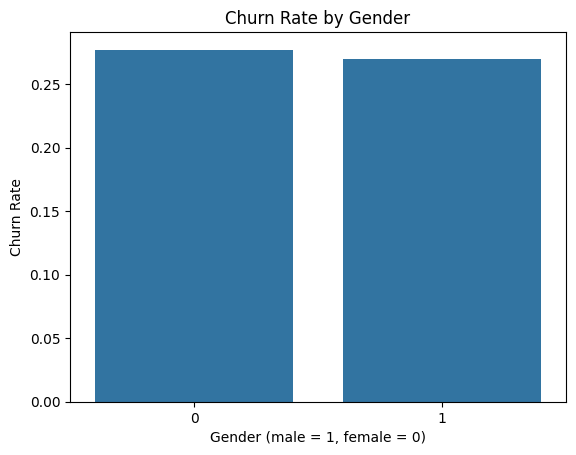

In [179]:
# # 01. churn distribution by genrder
churn_rate = (
    df.groupby('gender')['Churn']
      .mean()
      .reset_index()
)

sns.barplot(data=churn_rate, x='gender', y='Churn')
plt.ylabel("Churn Rate")
plt.xlabel("Gender (male = 1, female = 0)")
plt.title("Churn Rate by Gender")
plt.show()

### insight
## Churn Distribution by Gender

From the chart, we can observe the following:

- **Male customers (1)** and **Female customers (0)** both show a very 
  **similar churn rate** (~1000 each), with no significant difference 
  between the two groups.
- The no-churn counts are also nearly equal, with Males (~2650) and 
  Females (~2700) being almost identical.

> **Key Insight:** **Gender has little to no impact on churn**. Both male 
> and female customers churn at almost the same rate, meaning gender is 
> **not a strong predictor** of customer churn in this dataset.

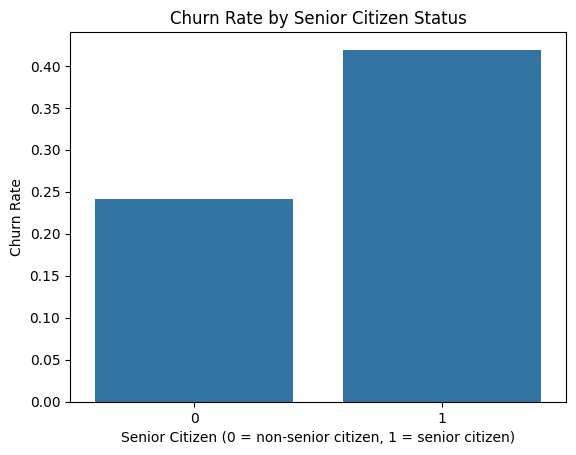

In [180]:
# 02. churn distribution by SeniorCitizen
churn_rate_of_senior_citizens = (
    df.groupby('SeniorCitizen')['Churn'].mean().reset_index())
sns.barplot(data=churn_rate_of_senior_citizens, x='SeniorCitizen', y='Churn')
plt.xlabel("Senior Citizen (0 = non-senior citizen, 1 = senior citizen)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Senior Citizen Status")
plt.show()

From the chart, we can observe the following:

- **Non-Senior Citizens (0)** have a **higher churn count** (~1300) in absolute numbers, 
  but given their much larger total population (~2500 no-churn), their 
  **churn rate is relatively moderate**.
- **Senior Citizens (1)** have a **lower churn count** (~750), but considering 
  their smaller no-churn base (~2800), their **churn rate is proportionally higher**, 
  making them a more at-risk group.

> **Key Insight:** Although **Senior Citizens** churn less in absolute numbers, 
> they represent a **proportionally higher churn risk** compared to non-senior citizens. 
> This could be due to factors such as **fixed income constraints**, **difficulty 
> adapting to new services**, or **lack of technical support**, which may push 
> them to cancel their subscriptions.


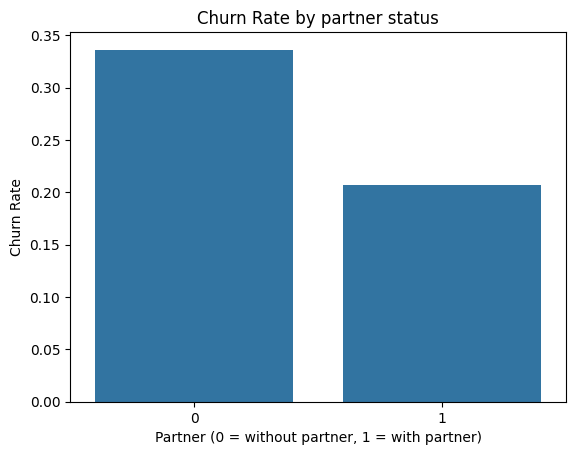

In [181]:
# churn distribution by Partner
churn_rate_of_partner = (
    df.groupby('Partner')['Churn'].mean().reset_index())
sns.barplot(data=churn_rate_of_partner, x='Partner', y='Churn')
plt.xlabel("Partner (0 = without partner, 1 = with partner)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by partner status")
plt.show()

In [182]:
pd.crosstab(df['Partner'], df['Dependents'], normalize='index')

Dependents,0,1
Partner,,
0,0.885103,0.114897
1,0.484678,0.515322



From the chart, we can observe the following:

- Customers **without a Partner (0)** have a **higher churn rate** (~1300), 
  meaning they are more likely to leave compared to customers with a partner.
- Customers **with a Partner (1)** have a **lower churn rate** (~750), 
  suggesting that having a partner contributes to greater customer stability 
  and loyalty.

> **Key Insight:** Customers **without a partner** are nearly **2x more likely to churn** 
> compared to those with a partner. This could suggest that customers with a partner 
> tend to have more **shared responsibilities and financial commitments**, making them 
> less likely to switch providers.

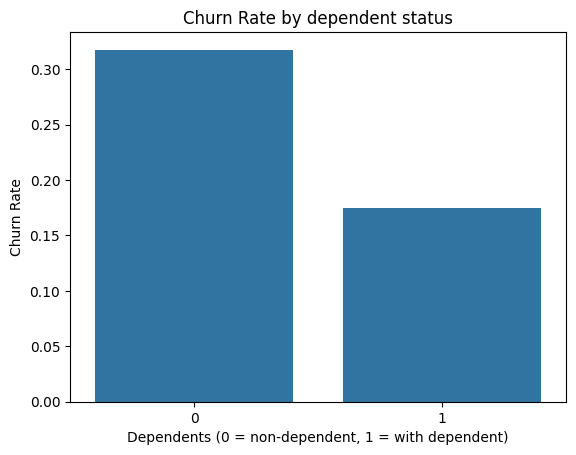

In [183]:
# 03. Dependents distribution by Churn
churn_rate_of_dependent = (
    df.groupby('Dependents')['Churn'].mean().reset_index())
sns.barplot(data=churn_rate_of_dependent, x='Dependents', y='Churn')
plt.xlabel("Dependents (0 = non-dependent, 1 = with dependent)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by dependent status")
plt.show()

In [184]:
df.groupby('Dependents')['Churn'].mean() * 100


Dependents
0    31.743842
1    17.504409
Name: Churn, dtype: float64


From the chart, we can observe the following:

- Customers **without Dependents (0)** have a **higher churn rate** (~1600), 
  meaning they are more likely to leave compared to customers with dependents.
- Customers **with Dependents (1)** have a **significantly lower churn rate** (~400), 
  suggesting that having dependents makes customers more stable and committed 
  to staying with the service.

> **Key Insight:** Customers **without dependents** are nearly **4x more likely to churn** 
> compared to those with dependents. This could suggest that customers with dependents 
> have **greater household responsibilities**, making them less likely to switch providers 
> due to the **inconvenience of changing services** for their family.

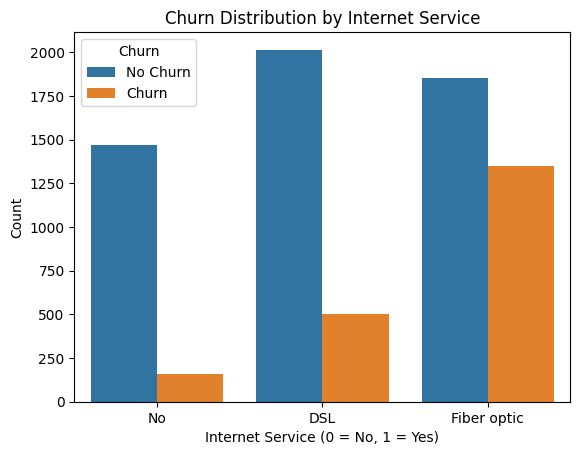

In [185]:
# churn distribution by internet service
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No Churn", "Churn"])
plt.show()


From the chart, we can observe the following:

- Customers **without internet service** have the **lowest churn rate**, meaning they are less likely to leave.
- Customers with **DSL** internet service churn more than those without internet, but still maintain a **relatively low churn rate**.
- Customers with **Fiber Optic** service have the **highest churn rate**, with churn counts nearly matching their no-churn counts.

> **Key Insight:** Fiber Optic customers are significantly more likely to churn compared to other groups.  
> Possible reasons include **dissatisfaction with service quality**, **higher pricing**, or **unmet expectations** — which may require further investigation.

In [186]:
# churn distribution by contract type
def churn_rate_table(feature):
    return (
        df.groupby(feature)['Churn']
          .mean()
          .sort_values(ascending=False)
    )

churn_rate_table('Contract') 



Contract
Month-to-month    0.428751
One year          0.134395
Two year          0.049245
Name: Churn, dtype: float64

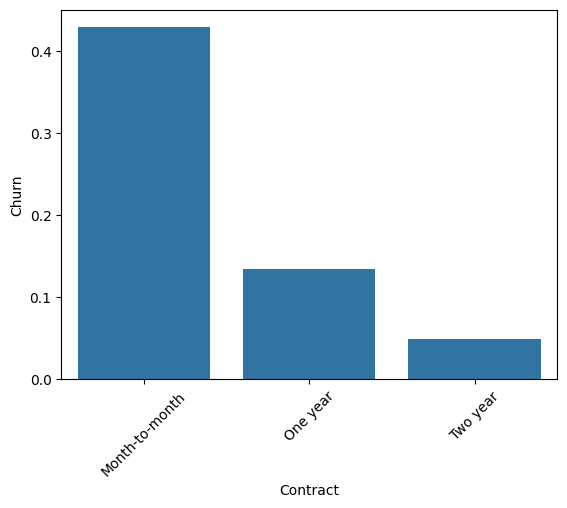

In [187]:
def plot_churn_rate(feature):
    rates = df.groupby(feature)['Churn'].mean().reset_index()
    sns.barplot(data=rates, x=feature, y='Churn')
    plt.xticks(rotation=45)
    plt.show()

plot_churn_rate('Contract') 

## Churn Distribution by Contract Type

From the chart, we can observe the following:

- **Month-to-Month** contracts have the **highest churn rate** (~1700), 
  with churn counts nearly matching no-churn counts (~2300), making it 
  the most at-risk contract type.
- **One Year** contracts show a **significantly lower churn rate** (~200), 
  indicating that longer commitments improve customer retention.
- **Two Year** contracts have the **lowest churn rate** (~100), suggesting 
  that customers on long-term contracts are the most loyal and least 
  likely to leave.

> **Key Insight:** The **shorter the contract**, the **higher the churn risk**. 
> Customers on **Month-to-Month** plans are far more likely to churn compared 
> to those on **One Year** or **Two Year** contracts. This suggests that 
> encouraging customers to commit to **longer-term contracts** could be an 
> effective strategy to **reduce churn**.

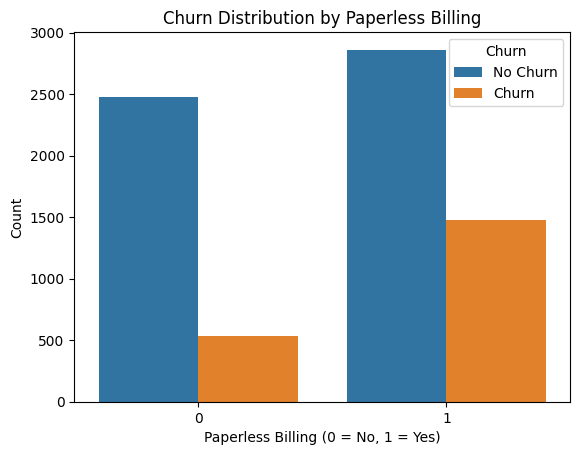

In [188]:
# churn distribution by paperless billing
sns.countplot(x='PaperlessBilling', hue='Churn', data=df)
plt.title("Churn Distribution by Paperless Billing")
plt.xlabel("Paperless Billing (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No Churn", "Churn"])
plt.show()

## Churn Distribution by Paperless Billing

From the chart, we can observe the following:

- Customers **without Paperless Billing (0)** have a **lower churn rate** (~500), 
  meaning they are less likely to leave compared to those with paperless billing.
- Customers **with Paperless Billing (1)** have a **significantly higher churn rate** 
  (~1500), with churn counts being nearly half of their no-churn counts (~2800), 
  making them the more at-risk group.

> **Key Insight:** Customers who use **Paperless Billing** are **3x more likely to churn** 
> compared to those who do not. This could suggest that customers on paperless billing 
> may be more **digitally engaged** and therefore more likely to **explore and switch** 
> to competitors offering better deals online.

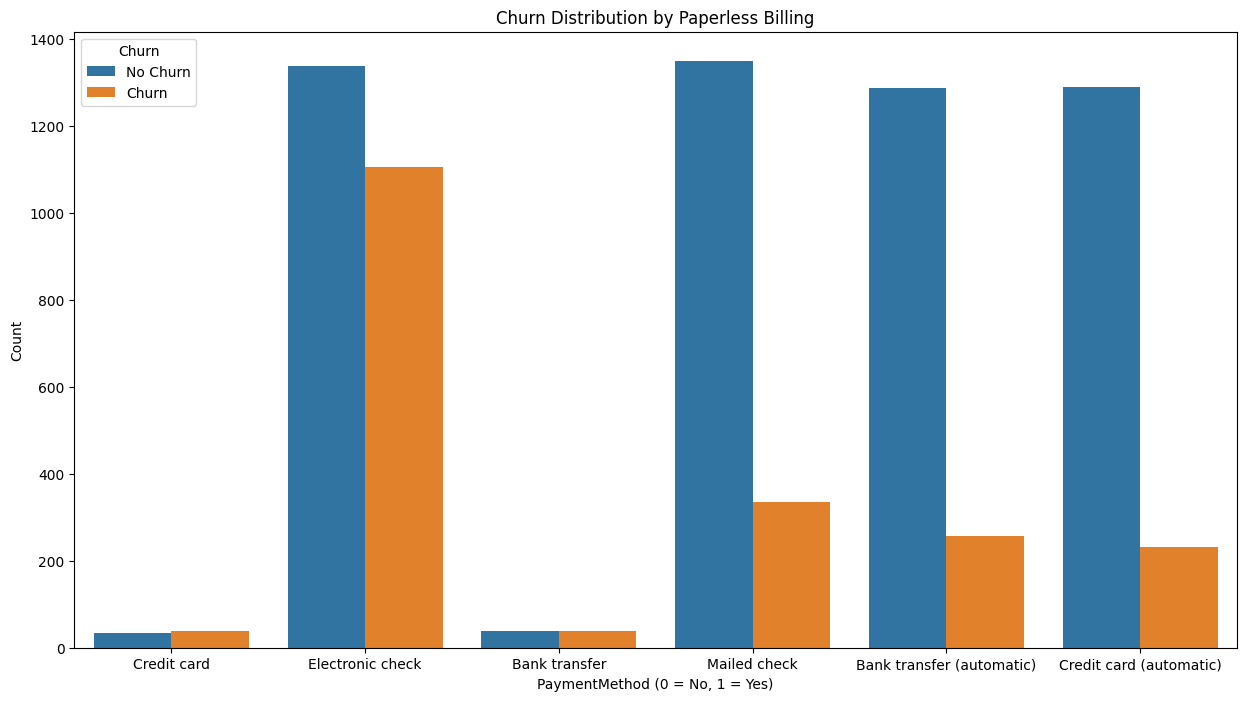

In [189]:
# churn distribution by PaymentMethod
plt.figure(figsize=(15, 8))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn Distribution by Paperless Billing")
plt.xlabel("PaymentMethod (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["No Churn", "Churn"])
plt.show()

## Churn Distribution by Payment Method

From the chart, we can observe the following:

- **Electronic Check** has the **highest churn rate** by far, with churn counts (~1100) 
  nearly matching no-churn counts (~1340), making it the most concerning payment method.
- **Mailed Check** has a **moderate churn rate** (~340), significantly lower than 
  electronic check.
- **Automatic payment methods** such as **Bank Transfer (Automatic)** and 
  **Credit Card (Automatic)** have the **lowest churn rates** (~260 and ~240), 
  suggesting that customers on auto-pay tend to stay longer.
- **Credit Card** and **Bank Transfer** (non-automatic) have very **few customers overall**, 
  making their churn rates less meaningful to compare.

> **Key Insight:** Customers paying via **Electronic Check** are significantly more 
> likely to churn. In contrast, customers using **automatic payment methods** show 
> much better retention. This could suggest that the **convenience of auto-pay** 
> reduces the likelihood of cancellation.

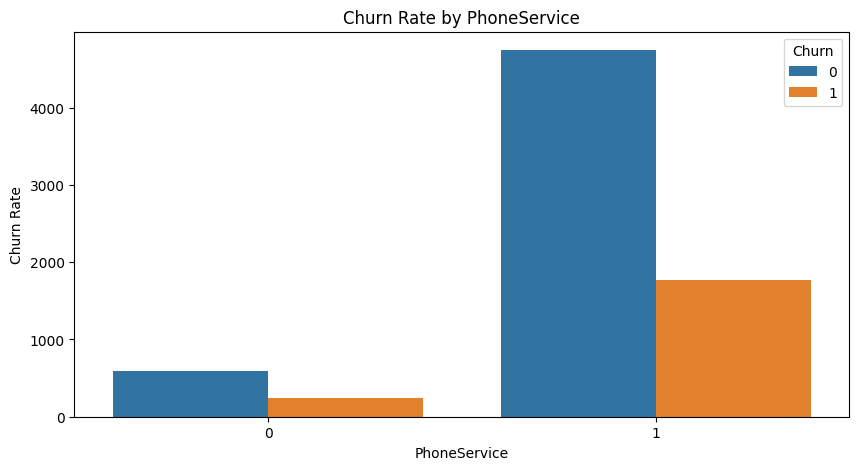

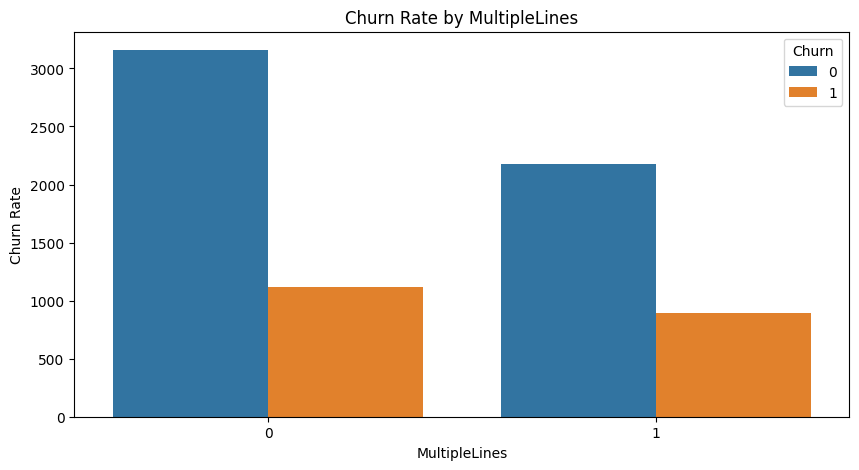

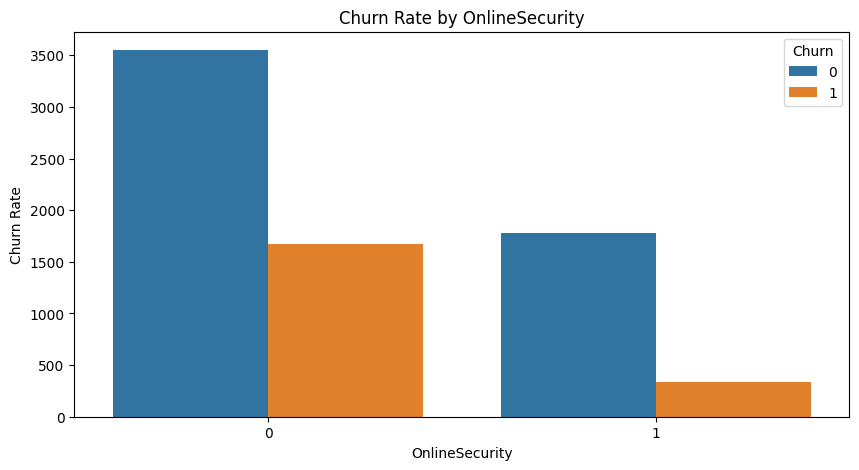

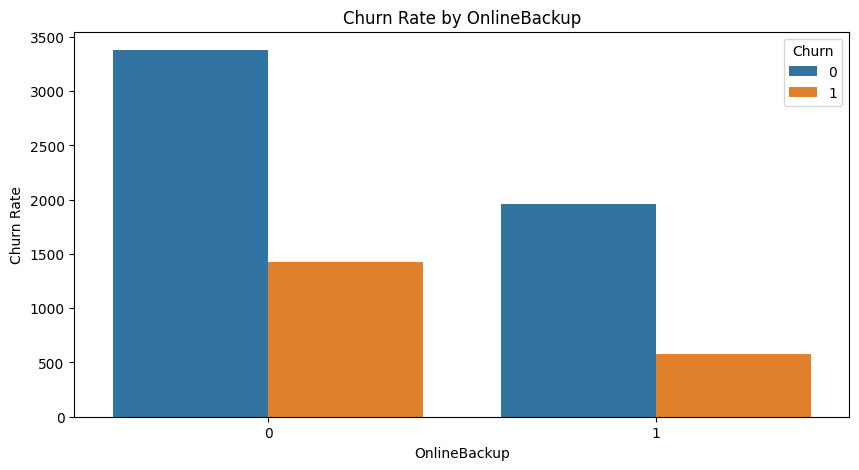

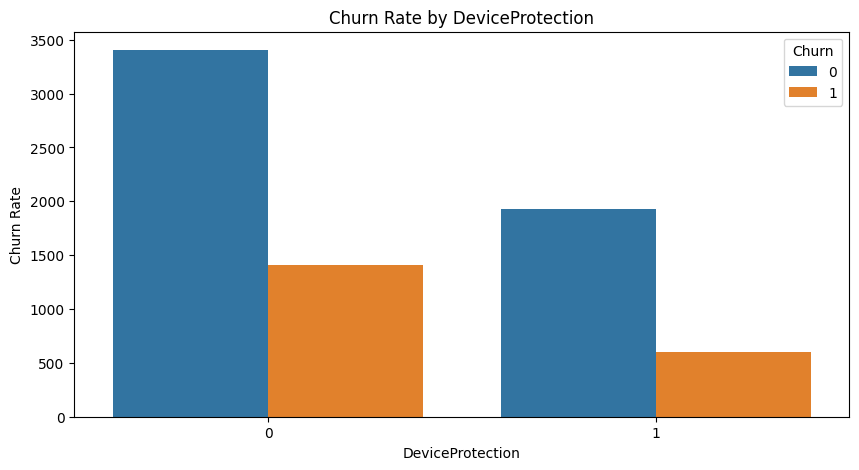

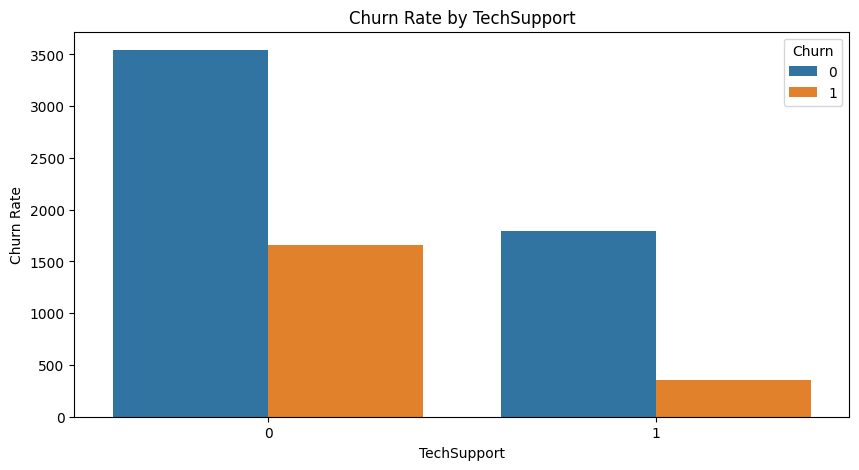

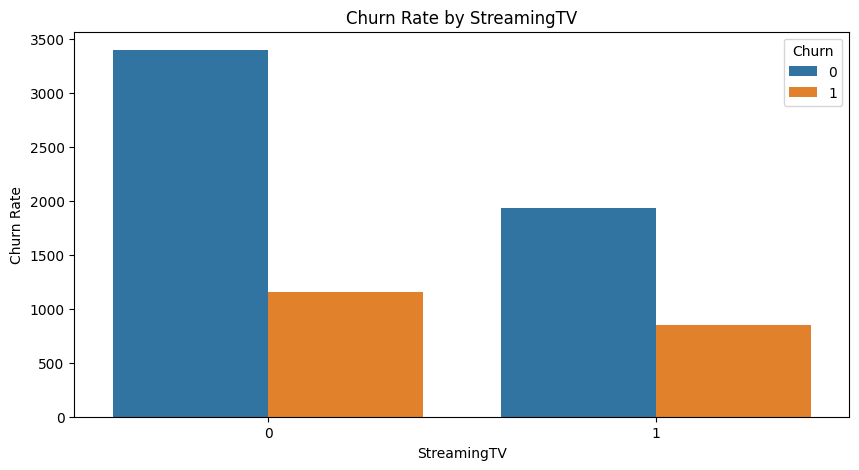

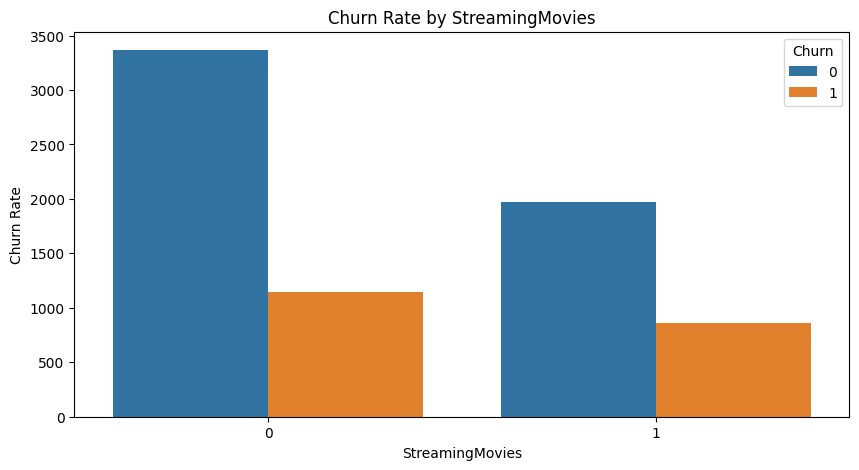

In [190]:
columns = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

for col in columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.show()

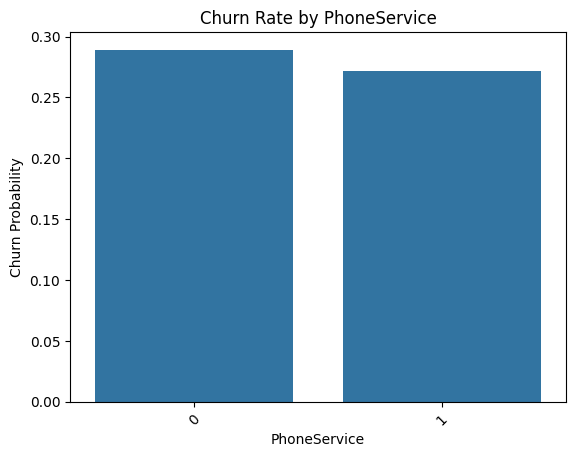

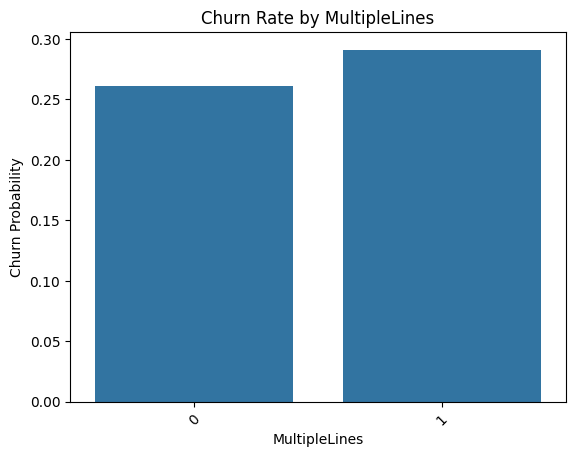

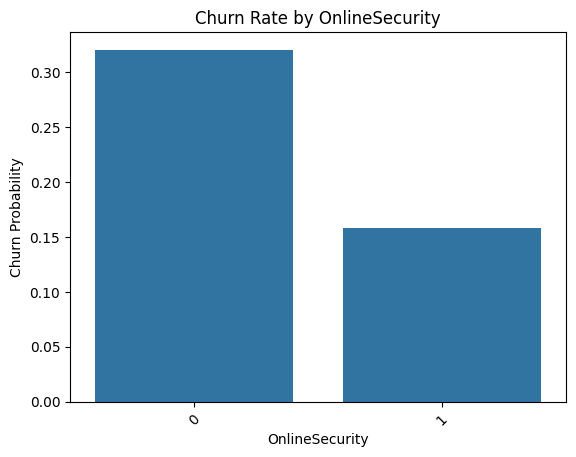

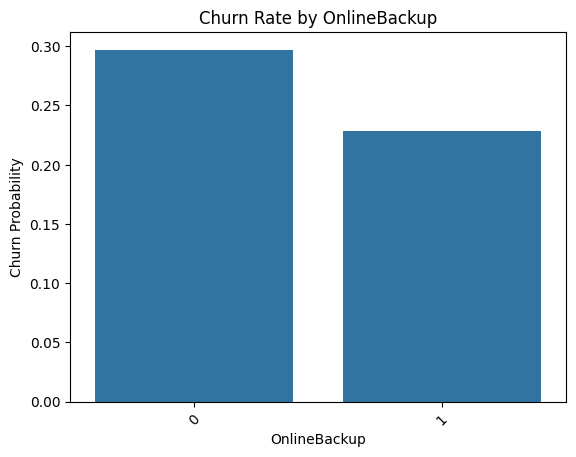

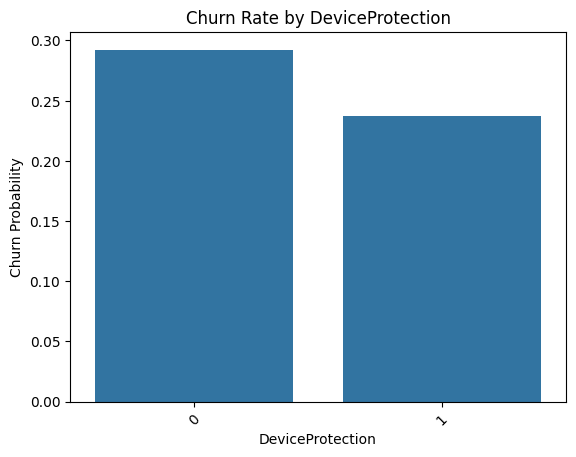

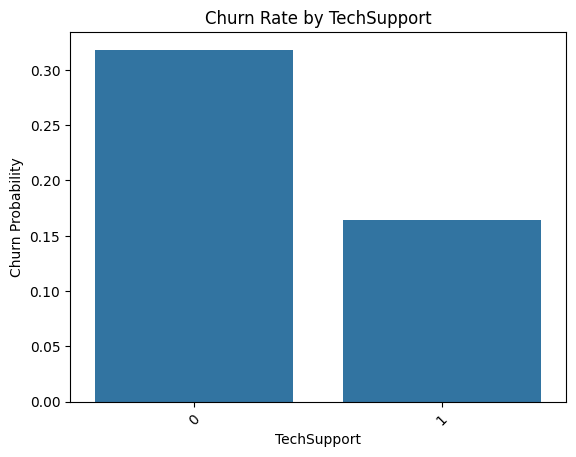

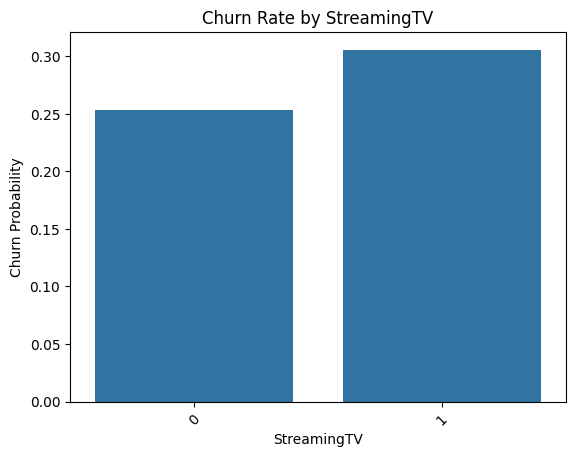

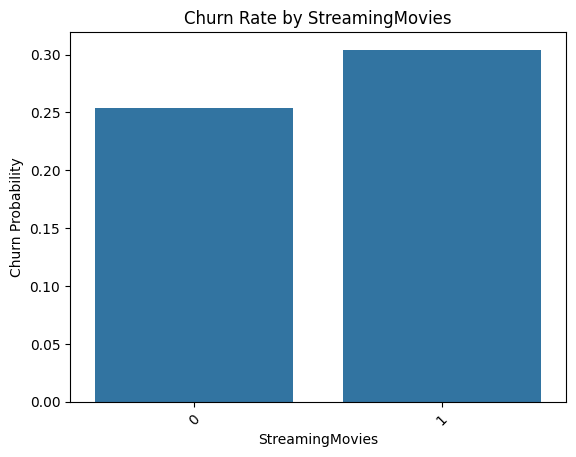

In [191]:
def plot_churn_rate(feature):
    rates = (
        df.groupby(feature)['Churn']
          .mean()
          .reset_index()
    )
    
    sns.barplot(data=rates, x=feature, y='Churn')
    plt.title(f"Churn Rate by {feature}")
    plt.ylabel("Churn Probability")
    plt.xticks(rotation=45)
    plt.show()

for col in columns:
    plot_churn_rate(col)

In [192]:
print(df['Churn'].dtype)
print(df['Churn'].unique())

int64
[1 0]


/tmp/ipykernel_4310/716450550.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Churn', 'Churn'])


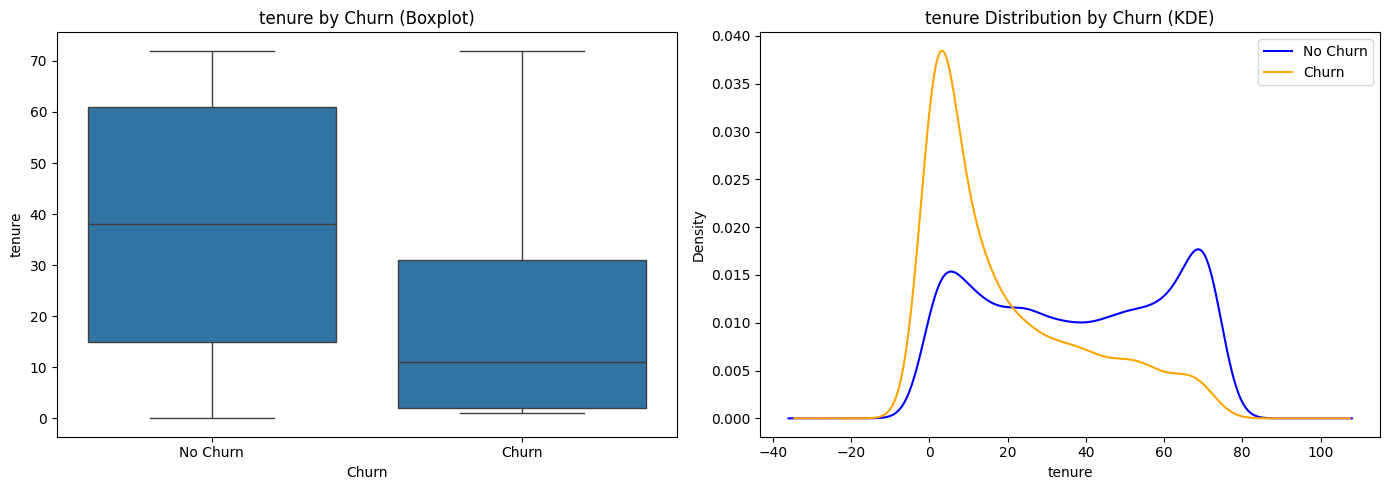

/tmp/ipykernel_4310/716450550.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Churn', 'Churn'])


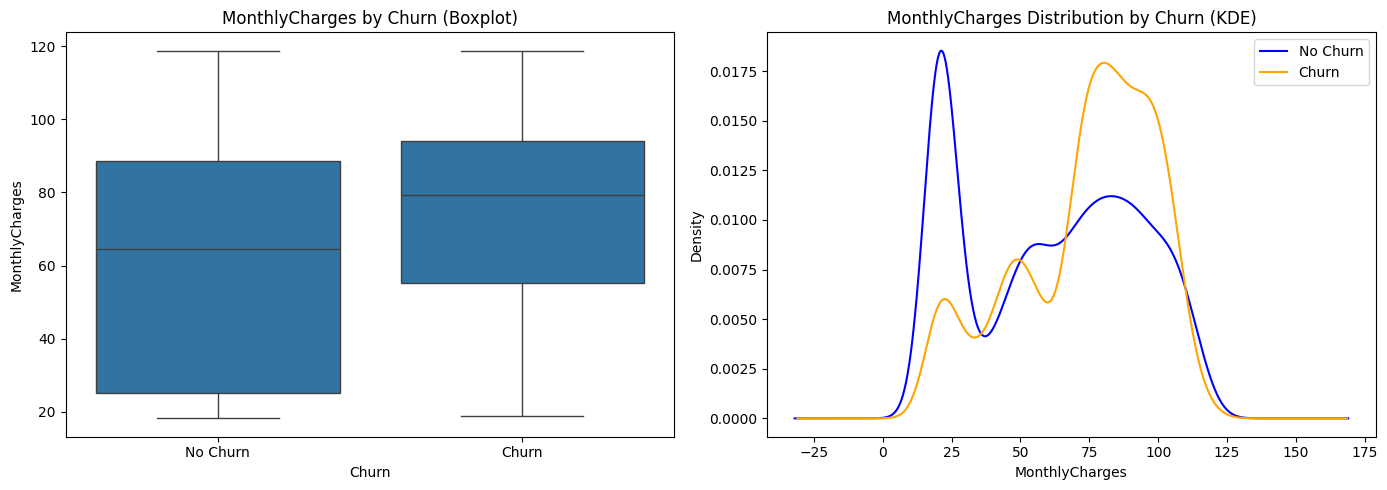

In [193]:
# numerical features distribution by churn
numerical_cols = ['tenure', 'MonthlyCharges']

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot - LEFT
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[0])
    axes[0].set_title(f'{col} by Churn (Boxplot)')
    axes[0].set_xticklabels(['No Churn', 'Churn'])
    
    # KDE - RIGHT
    df[df['Churn'] == 0][col].plot(kind='kde', ax=axes[1], label='No Churn', color='blue')
    df[df['Churn'] == 1][col].plot(kind='kde', ax=axes[1], label='Churn', color='orange')
    axes[1].set_title(f'{col} Distribution by Churn (KDE)')
    axes[1].set_xlabel(col)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

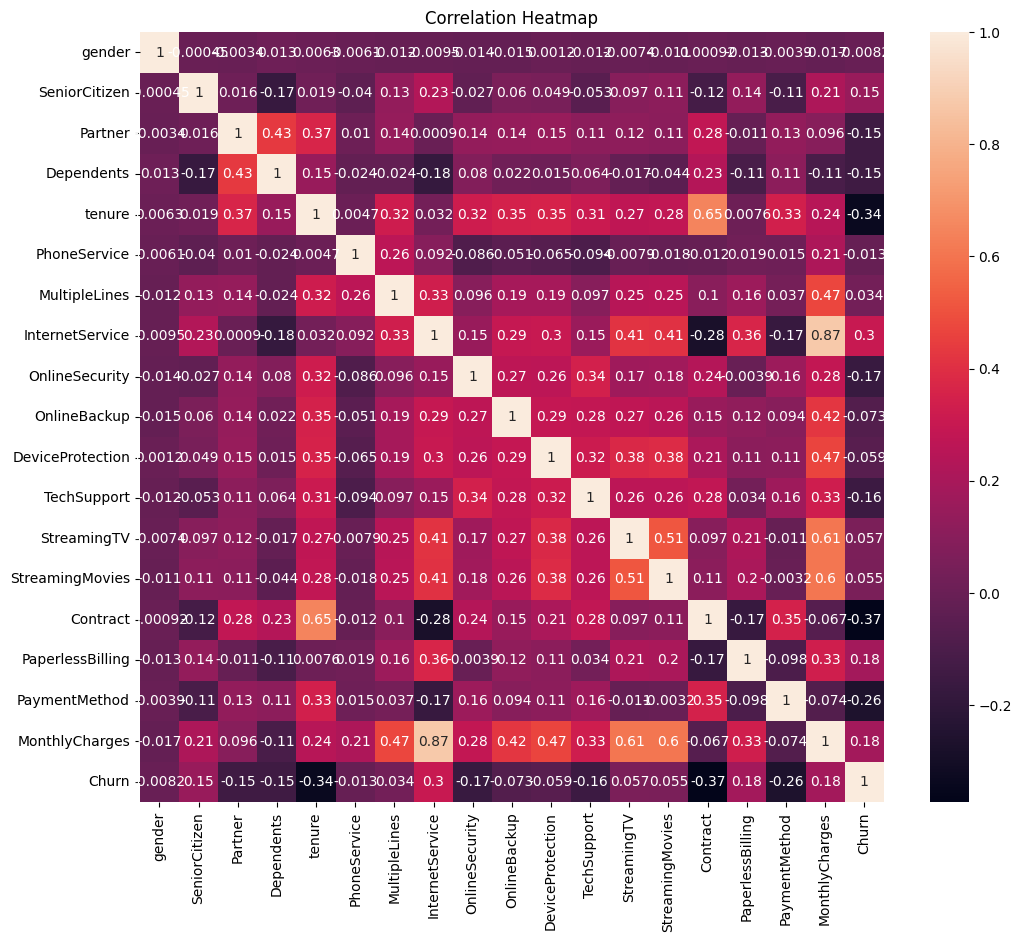

In [194]:
# create a temp copy just for the heatmap
df_temp = df.copy()
df_temp['InternetService'] = df_temp['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df_temp['Contract'] = df_temp['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_temp['PaymentMethod'] = df_temp['PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3})

# heatmap using temp copy
plt.figure(figsize=(12, 10))
sns.heatmap(df_temp.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

- Dark Purple/Black  →  close to -1  (strong negative)
- Medium Purple      →  close to  0  (weak/no relationship)
- Pink/Light         →  close to 0.5 (moderate positive)
- White/Bright       →  close to  1  (strong positive)

### The Rule of Thumb

- Above 0.3 → strong, definitely keep
- 0.1 to 0.3 → moderate, worth investigating
- Below 0.1 → likely noise, probably drop